In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [44]:
df = pd.read_csv("../data/risk_factors_cervical_cancer.csv")

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [45]:
print("Dataset shape:", df.shape)

Dataset shape: (858, 36)


In [46]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [48]:
df = df.replace("?", np.nan)

df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [49]:
df = df.apply(pd.to_numeric)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-n

In [50]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

STDs: Time since last diagnosis       787
STDs: Time since first diagnosis      787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:pelvic inflammatory disease      105
STDs:vulvo-perineal condylomatosis    105
STDs:HPV                              105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs:AIDS                             105
STDs:molluscum contagiosum            105
STDs:genital herpes                   105
STDs:syphilis                         105
STDs:vaginal condylomatosis           105
STDs:cervical condylomatosis          105
STDs:condylomatosis                   105
STDs (number)                         105
STDs                                  105
Num of pregnancies                     56
Number of sexual partners              26
Smokes (packs/year)                    13
Smokes (years)                    

In [51]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage

STDs: Time since last diagnosis       91.724942
STDs: Time since first diagnosis      91.724942
IUD                                   13.636364
IUD (years)                           13.636364
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
STDs:pelvic inflammatory disease      12.237762
STDs:vulvo-perineal condylomatosis    12.237762
STDs:HPV                              12.237762
STDs:Hepatitis B                      12.237762
STDs:HIV                              12.237762
STDs:AIDS                             12.237762
STDs:molluscum contagiosum            12.237762
STDs:genital herpes                   12.237762
STDs:syphilis                         12.237762
STDs:vaginal condylomatosis           12.237762
STDs:cervical condylomatosis          12.237762
STDs:condylomatosis                   12.237762
STDs (number)                         12.237762
STDs                                  12.237762
Num of pregnancies                     6

In [52]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_clean = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

df_clean.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18.0,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15.0,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,34.0,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,52.0,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,4.0,3.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,46.0,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
df_clean.isnull().sum().sum()

np.int64(0)

In [54]:
## Section 2: Target Selection and Feature Preparation

# In this section, we define the prediction goal of the project. The dataset contains four diagnostic result columns: `Hinselmann`, `Schiller`, `Citology`, and `Biopsy`.

# For this project, `Biopsy` is selected as the target variable because it represents an important diagnostic outcome. The other diagnostic result columns are removed from the input features to avoid data leakage.

# The data will be separated into:

# - `X`: input features used by the model
# - `y`: target variable, which is the biopsy result

In [55]:
diagnostic_columns = ["Hinselmann", "Schiller", "Citology", "Biopsy"]

df_clean[diagnostic_columns].head()

,Hinselmann,Schiller,Citology,Biopsy
0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0


In [56]:
df_clean["Biopsy"].value_counts()

Biopsy
0.0    803
1.0     55
Name: count, dtype: int64

In [57]:
df_clean["Biopsy"].value_counts(normalize=True) * 100

Biopsy
0.0    93.589744
1.0     6.410256
Name: proportion, dtype: float64

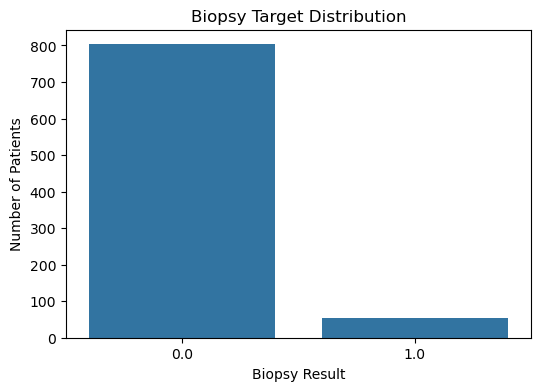

In [58]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_clean["Biopsy"])
plt.title("Biopsy Target Distribution")
plt.xlabel("Biopsy Result")
plt.ylabel("Number of Patients")
plt.show()

In [59]:
# ### Class Distribution Observation

# After selecting `Biopsy` as the target variable, we examined its distribution and found that the dataset is highly imbalanced. Approximately 93.6% of the samples belong to class `0`, while only 6.4% belong to class `1`.

# This means that negative biopsy cases are much more common than positive biopsy cases. Because of this imbalance, accuracy alone is not a reliable evaluation metric. In the later modeling stages, more informative metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will be used. Stratified splitting and class balancing techniques will also be considered.

In [60]:
# ## Section 3: Train-Test Split

# In this section, the dataset was divided into training and testing sets. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen data.

# An 80/20 split was used, where 80% of the data was used for training and 20% was used for testing. The parameter `random_state=42` was used to make the split reproducible.

# Since the target variable `Biopsy` is highly imbalanced, `stratify=y` was used during the split. This ensures that both the training and testing sets keep approximately the same class distribution as the original dataset.

In [61]:
target = "Biopsy"

X = df_clean.drop(columns=["Hinselmann", "Schiller", "Citology", "Biopsy"])
y = df_clean[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (858, 32)
Target shape: (858,)


In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (686, 32)
X_test: (172, 32)
y_train: (686,)
y_test: (172,)


In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced")

In [64]:
# ## Section 4: Baseline Model Training and Evaluation

# In this section, several baseline classification models are trained and evaluated. Since the target variable `Biopsy` is binary, this is a binary classification problem.

# The models used in this section are:

# - Logistic Regression
# - Decision Tree
# - Random Forest
# - Support Vector Machine
# - K-Nearest Neighbors

# These models are trained using the same training set and evaluated using the same test set. Because the dataset is highly imbalanced, accuracy alone is not enough. Therefore, precision, recall, F1-score, ROC-AUC, and the confusion matrix are used to evaluate model performance.

# Models that support class balancing use `class_weight="balanced"` to give more importance to the minority class.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)